# Notebook 05 — Summary Analysis & Experiment Report (V2)
**Thesis**: A Prescriptive and Explainable Hybrid ML Framework for T2D Risk Prediction
**Dataset**: DiaHealth (single dataset)

This notebook consolidates results from Notebooks 01-04 and produces:
1. Dataset characteristics table
2. Model performance comparison table
3. Boruta feature selection summary
4. SHAP feature importance analysis
5. Counterfactual quality summary
6. Thesis-ready LaTeX tables
7. Comprehensive experiment report (Markdown)


In [ ]:
!pip install -q "scipy>=1.14.0,<1.17" "seaborn>=0.13.2" --upgrade



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
print('All imports successful.')


All imports successful.


## 2. Load All Results

In [ ]:
# ============================================================
# 2. LOAD ALL RESULTS
# ============================================================
EXP_DIR       = '/kaggle/working/exp_v2'
CKPT_DIR      = os.path.join(EXP_DIR, 'checkpoints')  # for reference only (NB05 does not write checkpoints)
PROCESSED_DIR = os.path.join(EXP_DIR, 'data', 'processed')
MODELS_DIR    = os.path.join(EXP_DIR, 'models')
XAI_DIR       = os.path.join(EXP_DIR, 'results', 'xai')
CF_DIR        = os.path.join(EXP_DIR, 'results', 'counterfactuals')
SUMMARY_DIR   = os.path.join(EXP_DIR, 'results', 'summary')
os.makedirs(SUMMARY_DIR, exist_ok=True)

# Processed data
d          = joblib.load(os.path.join(PROCESSED_DIR, 'diahealth_processed.pkl'))
meta       = joblib.load(os.path.join(PROCESSED_DIR, 'meta.pkl'))

X_train    = d['X_train_boruta']    # original (non-resampled) for size reporting
X_test     = d['X_test_boruta']
y_train    = d['y_train']
y_test     = d['y_test']
FEATURES   = d['feature_names_boruta']
TARGET_COL = d['target_col']

# Model results
results_csv = os.path.join(EXP_DIR, 'results', 'model_comparison.csv')
if os.path.exists(results_csv):
    results_df = pd.read_csv(results_csv)
else:
    results_df = pd.DataFrame()

# XAI
xai_path = os.path.join(XAI_DIR, 'xai_results.pkl')
xai_output = joblib.load(xai_path) if os.path.exists(xai_path) else {}

# CF
cf_path = os.path.join(CF_DIR, 'cf_results.pkl')
cf_output = joblib.load(cf_path) if os.path.exists(cf_path) else {}

print('All results loaded.')
print(f'  Processed data shape: Train={X_train.shape}  Test={X_test.shape}')
print(f'  Model results: {len(results_df)} rows')


All results loaded.
  Processed data shape: Train=(4349, 16)  Test=(1088, 16)
  Model results: 4 rows


## 3. Dataset Characteristics Table

In [ ]:
# ============================================================
# 3. DATASET CHARACTERISTICS
# ============================================================
n_total   = len(X_train) + len(X_test)
pos_rate  = y_test.mean()

chars = pd.DataFrame([{
    'Dataset':            'DiaHealth',
    'N (total)':          n_total,
    'N (train)':          len(X_train),
    'N (test)':           len(X_test),
    'All features':       len(d['feature_names_full']),
    'Boruta selected':    len(FEATURES),
    'Boruta confirmed':   len(d['boruta_confirmed']),
    'Boruta tentative':   len(d['boruta_tentative']),
    'Positive rate':      f'{pos_rate:.2%}',
    'Class ratio':        f'1:{int(1/pos_rate):.0f}',
}])

print('TABLE 1: Dataset Characteristics')
print('='*60)
display(chars)

print('\nLaTeX:')
print(chars.to_latex(index=False))

chars.to_csv(os.path.join(SUMMARY_DIR, 'table_dataset_characteristics.csv'), index=False)
print('Saved table_dataset_characteristics.csv')


TABLE 1: Dataset Characteristics


,Dataset,N (total),N (train),N (test),All features,Boruta selected,Boruta confirmed,Boruta tentative,Positive rate,Class ratio
0,DiaHealth,5437,4349,1088,20,16,14,2,6.34%,1:15



LaTeX:
\begin{tabular}{lrrrrrrrll}
\toprule
Dataset & N (total) & N (train) & N (test) & All features & Boruta selected & Boruta confirmed & Boruta tentative & Positive rate & Class ratio \\
\midrule
DiaHealth & 5437 & 4349 & 1088 & 20 & 16 & 14 & 2 & 6.34% & 1:15 \\
\bottomrule
\end{tabular}

Saved table_dataset_characteristics.csv


## 4. Model Performance Table

In [ ]:
# ============================================================
# 4. MODEL PERFORMANCE TABLE
# ============================================================
if len(results_df) > 0:
    perf_cols = ['model', 'accuracy', 'precision', 'recall', 'f1', 'auc_roc', 'auc_pr', 'brier']
    avail     = [c for c in perf_cols if c in results_df.columns]
    perf_df   = results_df[avail].copy()

    print('TABLE 2: Model Performance — DiaHealth')
    print('='*60)
    display(perf_df.sort_values('auc_roc', ascending=False))

    best_row  = perf_df.loc[perf_df['auc_roc'].idxmax()]
    print(f'\nBest model: {best_row["model"]}')
    print(f'  AUC-ROC  : {best_row["auc_roc"]:.4f}')
    print(f'  F1       : {best_row["f1"]:.4f}')
    print(f'  Accuracy : {best_row["accuracy"]:.4f}')

    perf_df.to_csv(os.path.join(SUMMARY_DIR, 'table_model_performance.csv'), index=False)
    print('\nLaTeX:')
    print(perf_df.to_latex(index=False, float_format='%.4f'))
else:
    print('No model results found. Run 02_modelling.ipynb first.')


TABLE 2: Model Performance — DiaHealth


,model,accuracy,precision,recall,f1,auc_roc,auc_pr,brier
3,AutoGluon,0.945772,0.708333,0.246377,0.365591,0.885793,0.488213,0.043848
0,XGBoost,0.911765,0.341176,0.420290,0.376623,0.820298,0.291439,0.071109
1,LightGBM,0.915441,0.338028,0.347826,0.342857,0.819701,0.297091,0.066484
2,CatBoost,0.915441,0.317460,0.289855,0.303030,0.808479,0.272522,0.068250



Best model: AutoGluon
  AUC-ROC  : 0.8858
  F1       : 0.3656
  Accuracy : 0.9458

LaTeX:
\begin{tabular}{lrrrrrrr}
\toprule
model & accuracy & precision & recall & f1 & auc_roc & auc_pr & brier \\
\midrule
XGBoost & 0.9118 & 0.3412 & 0.4203 & 0.3766 & 0.8203 & 0.2914 & 0.0711 \\
LightGBM & 0.9154 & 0.3380 & 0.3478 & 0.3429 & 0.8197 & 0.2971 & 0.0665 \\
CatBoost & 0.9154 & 0.3175 & 0.2899 & 0.3030 & 0.8085 & 0.2725 & 0.0682 \\
AutoGluon & 0.9458 & 0.7083 & 0.2464 & 0.3656 & 0.8858 & 0.4882 & 0.0438 \\
\bottomrule
\end{tabular}



## 5. Boruta Feature Summary

In [ ]:
# ============================================================
# 5. BORUTA FEATURE SUMMARY
# ============================================================
boruta_df = pd.DataFrame([{
    'Status':   'Confirmed',
    'Features': ', '.join(d['boruta_confirmed']),
    'Count':    len(d['boruta_confirmed']),
}, {
    'Status':   'Tentative',
    'Features': ', '.join(d['boruta_tentative']),
    'Count':    len(d['boruta_tentative']),
}, {
    'Status':   'Rejected',
    'Features': ', '.join(d['boruta_rejected'][:10]) + ('...' if len(d['boruta_rejected']) > 10 else ''),
    'Count':    len(d['boruta_rejected']),
}])

print('TABLE 3: Boruta Feature Selection — DiaHealth')
print('='*60)
display(boruta_df[['Status', 'Count', 'Features']])
boruta_df.to_csv(os.path.join(SUMMARY_DIR, 'table_boruta_results.csv'), index=False)
print('Saved table_boruta_results.csv')


TABLE 3: Boruta Feature Selection — DiaHealth


,Status,Count,Features
0,Confirmed,14,"age, gender, pulse_rate, systolic_bp, diastoli..."
1,Tentative,2,"family_hypertension, family_risk"
2,Rejected,4,"height, family_diabetes, cardiovascular_diseas..."


Saved table_boruta_results.csv


## 6. SHAP Feature Importance Summary

TABLE 4: SHAP Feature Importance — DiaHealth


,Feature,Mean |SHAP|
0,glucose,1.453824
1,weight,0.895549
2,bmi_age,0.810698
3,diastolic_bp,0.797423
4,glucose_bmi,0.501328
5,age,0.497931
6,pulse_rate,0.493210
7,bmi,0.452874
8,gender,0.367826
9,systolic_bp,0.336577


<Figure size 1000x600 with 0 Axes>

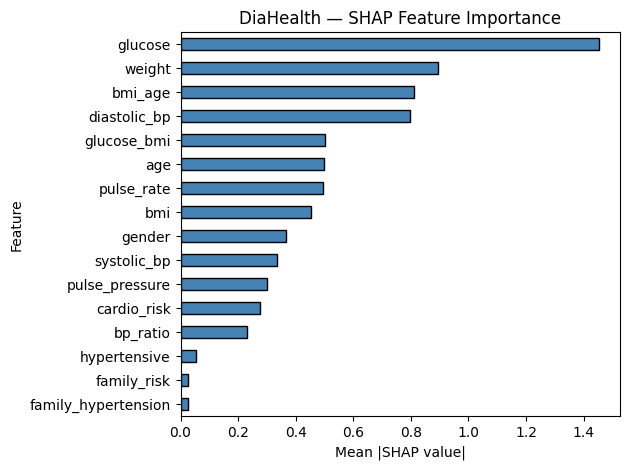

Saved table_shap_importance.csv


In [ ]:
# ============================================================
# 6. SHAP FEATURE IMPORTANCE
# ============================================================
if xai_output:
    shap_imp = pd.Series(xai_output['shap_importance'])
    shap_df  = shap_imp.sort_values(ascending=False).reset_index()
    shap_df.columns = ['Feature', 'Mean |SHAP|']

    print('TABLE 4: SHAP Feature Importance — DiaHealth')
    print('='*60)
    display(shap_df)

    plt.figure(figsize=(10, 6))
    shap_df.sort_values('Mean |SHAP|').plot(
        kind='barh', x='Feature', y='Mean |SHAP|',
        legend=False, color='steelblue', edgecolor='black')
    plt.title('DiaHealth — SHAP Feature Importance')
    plt.xlabel('Mean |SHAP value|')
    plt.tight_layout()
    plt.savefig(os.path.join(SUMMARY_DIR, 'shap_importance_summary.png'), dpi=150)
    plt.show()

    shap_df.to_csv(os.path.join(SUMMARY_DIR, 'table_shap_importance.csv'), index=False)
    print('Saved table_shap_importance.csv')
else:
    print('No XAI results. Run 03_xai.ipynb first.')


## 7. Counterfactual Quality Summary

In [ ]:
# ============================================================
# 7. CF QUALITY SUMMARY
# ============================================================
if cf_output:
    cf_comp_path = os.path.join(CF_DIR, 'cf_comparison.csv')
    if os.path.exists(cf_comp_path):
        cf_df = pd.read_csv(cf_comp_path)
        print('TABLE 5: Counterfactual Quality — DiaHealth')
        print('='*60)
        display(cf_df)
        cf_df.to_csv(os.path.join(SUMMARY_DIR, 'table_cf_quality.csv'), index=False)

    # Alignment distribution
    align = cf_output.get('alignment_results', {})
    rows  = []
    for method, scores in align.items():
        if scores:
            rows.append({
                'Method':          method,
                'N CFs':           len(scores),
                'Mean Alignment':  f'{np.mean(scores):.4f}',
                'Median Alignment': f'{np.median(scores):.4f}',
                'Std':             f'{np.std(scores):.4f}',
            })
    if rows:
        align_df = pd.DataFrame(rows)
        print('\nAlignment Score Summary:')
        display(align_df)
        align_df.to_csv(os.path.join(SUMMARY_DIR, 'table_cf_alignment.csv'), index=False)
else:
    print('No CF results. Run 04_counterfactuals.ipynb first.')


TABLE 5: Counterfactual Quality — DiaHealth


,method,alignment_mean,proximity_mean,sparsity_mean,validity,n_cfs
0,standard,0.752353,179.724294,0.804167,0.983333,60
1,shap_guided,0.660478,107.894630,0.490278,0.983333,60



Alignment Score Summary:


,Method,N CFs,Mean Alignment,Median Alignment,Std
0,standard,60,0.7524,0.7999,0.1735
1,shap_guided,60,0.6605,0.6808,0.1461


## 8. Comprehensive Experiment Report

In [ ]:
# ============================================================
# 8. GENERATE EXPERIMENT REPORT
# ============================================================
REPORT_PATH = os.path.join(EXP_DIR, 'experiment_report.md')
lines = []

lines.append('# Experiment Report — DiaHealth Diabetes ML Framework (V2)')
lines.append(f'**Generated**: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
lines.append('')
lines.append('## Dataset')
lines.append(f'- **Source**: DiaHealth Diabetes Dataset')
lines.append(f'- **Shape**: {len(X_train) + len(X_test)} rows x {len(d["feature_names_full"])} columns')
lines.append(f'- **Target**: `{TARGET_COL}` (binary: Yes=1, No=0)')
lines.append(f'- **Positive rate**: {y_test.mean():.2%} (highly imbalanced)')
lines.append(f'- **Train / Test**: {len(X_train)} / {len(X_test)} (80/20 stratified)')
lines.append('')
lines.append('## V2 Improvements')
for imp in meta.get('improvements', []):
    lines.append(f'- {imp}')
lines.append('')
lines.append('## Feature Engineering')
lines.append('| Feature | Description |')
lines.append('|---------|-------------|')
lines.append('| `bp_ratio` | systolic_bp / (diastolic_bp + 1) |')
lines.append('| `pulse_pressure` | systolic_bp - diastolic_bp |')
lines.append('| `bmi_age` | bmi x age interaction |')
lines.append('| `glucose_bmi` | glucose x bmi interaction |')
lines.append('| `cardio_risk` | hypertensive + cardiovascular_disease + stroke |')
lines.append('| `family_risk` | family_diabetes + family_hypertension |')
lines.append('')
lines.append('## Boruta Feature Selection')
lines.append(f'- Confirmed ({len(d["boruta_confirmed"])}): {d["boruta_confirmed"]}')
lines.append(f'- Tentative ({len(d["boruta_tentative"])}): {d["boruta_tentative"]}')
lines.append(f'- Selected total: {len(FEATURES)}')
lines.append('')

# Model results
if len(results_df) > 0:
    lines.append('## Model Performance')
    lines.append('')
    lines.append('| Model | Accuracy | Precision | Recall | F1 | AUC-ROC | Brier |')
    lines.append('|-------|----------|-----------|--------|----|---------|-------|')
    for _, row in results_df.sort_values('auc_roc', ascending=False).iterrows():
        lines.append(
            f'| {row.get("model","?")} | {row.get("accuracy",0):.4f} | '
            f'{row.get("precision",0):.4f} | {row.get("recall",0):.4f} | '
            f'{row.get("f1",0):.4f} | {row.get("auc_roc",0):.4f} | '
            f'{row.get("brier",0):.4f} |'
        )
    lines.append('')

# XAI
if xai_output:
    shap_imp  = pd.Series(xai_output['shap_importance'])
    top5      = shap_imp.sort_values(ascending=False).head(5)
    lines.append('## SHAP Feature Importance (Top-5)')
    lines.append('')
    lines.append('| Feature | Mean |SHAP| |')
    lines.append('|---------|-------------|')
    for f, v in top5.items():
        lines.append(f'| {f} | {v:.4f} |')
    lines.append('')

lines.append('---')
lines.append('*Report auto-generated by Notebook 05.*')

report_text = '\n'.join(lines)
with open(REPORT_PATH, 'w', encoding='utf-8') as f:
    f.write(report_text)

print(f'Report saved to {REPORT_PATH}')
print()
print(report_text[:1500])
print('...')


Report saved to /kaggle/working/exp_v2/experiment_report.md

# Experiment Report — DiaHealth Diabetes ML Framework (V2)
**Generated**: 2026-06-10 21:09:20

## Dataset
- **Source**: DiaHealth Diabetes Dataset
- **Shape**: 5437 rows x 20 columns
- **Target**: `diabetic` (binary: Yes=1, No=0)
- **Positive rate**: 6.34% (highly imbalanced)
- **Train / Test**: 4349 / 1088 (80/20 stratified)

## V2 Improvements

## Feature Engineering
| Feature | Description |
|---------|-------------|
| `bp_ratio` | systolic_bp / (diastolic_bp + 1) |
| `pulse_pressure` | systolic_bp - diastolic_bp |
| `bmi_age` | bmi x age interaction |
| `glucose_bmi` | glucose x bmi interaction |
| `cardio_risk` | hypertensive + cardiovascular_disease + stroke |
| `family_risk` | family_diabetes + family_hypertension |

## Boruta Feature Selection
- Confirmed (14): ['age', 'gender', 'pulse_rate', 'systolic_bp', 'diastolic_bp', 'glucose', 'weight', 'bmi', 'hypertensive', 'bp_ratio', 'pulse_pressure', 'bmi_age', 'glucose_bm

## 9. Final Output Summary

In [ ]:
# ============================================================
# 9. FINAL OUTPUT SUMMARY
# ============================================================
print('\n' + '='*70)
print('  ALL EXPERIMENTS COMPLETE!')
print('='*70)
print()
print('Output files:')

all_dirs = [
    os.path.join(EXP_DIR, 'results'),
    os.path.join(EXP_DIR, 'results', 'xai'),
    os.path.join(EXP_DIR, 'results', 'counterfactuals'),
    os.path.join(EXP_DIR, 'results', 'summary'),
    os.path.join(EXP_DIR, 'models'),
]

for d_path in all_dirs:
    if os.path.exists(d_path):
        files = os.listdir(d_path)
        if files:
            print(f'  {d_path.replace(EXP_DIR, "exp_v2")}/')
            for f in sorted(files):
                fpath = os.path.join(d_path, f)
                if os.path.isfile(fpath):
                    size = os.path.getsize(fpath)
                    print(f'    {f} ({size/1024:.1f} KB)')

print()
print('Next steps:')
print('  1. Review experiment_report.md')
print('  2. Insert LaTeX tables from results/summary/ into main.tex')
print('  3. Insert figures from results/xai/ and results/counterfactuals/ into thesis')
print()
print('Notebook 05 complete!')



  ALL EXPERIMENTS COMPLETE!

Output files:
  exp_v2/results/
    calibration.png (118.8 KB)
    confusion_matrices.png (33.1 KB)
    correlation_heatmap.png (478.2 KB)
    diahealth_roc_pr.png (125.8 KB)
    model_comparison.csv (1.7 KB)
    model_comparison_bar.png (35.1 KB)
  exp_v2/results/xai/
    lime_instance_0.png (75.3 KB)
    lime_instance_1.png (79.3 KB)
    shap_dep_bmi_age.png (136.5 KB)
    shap_dep_glucose.png (132.3 KB)
    shap_dep_weight.png (140.6 KB)
    shap_global_bar.png (82.6 KB)
    shap_global_beeswarm.png (249.3 KB)
    shap_local_0.png (88.7 KB)
    shap_local_1.png (90.3 KB)
    shap_local_2.png (91.5 KB)
    shap_subgroup_age.png (64.9 KB)
    shap_subgroup_bmi.png (69.7 KB)
    shap_vs_lime.png (68.2 KB)
    xai_results.pkl (214.6 KB)
  exp_v2/results/counterfactuals/
    alignment_distribution.png (37.1 KB)
    cf_comparison.csv (0.2 KB)
    cf_results.pkl (25.7 KB)
    comparison_metrics.png (67.8 KB)
    diahealth_shap_guided_cfs.csv (9.1 KB)
    diahe